In [1]:
%pip install scipy
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr, kendalltau

In [11]:
score_df = pd.read_csv('data-files/ch2_scores_em.csv')
score_df.set_index(["student number"], inplace=True)
english = score_df["english"]
math = score_df["mathematics"]
score_df

,english,mathematics
student number,,
1,42,65
2,69,80
3,56,63
4,41,63
5,57,76
6,48,60
7,65,81
8,49,66
9,65,78


In [4]:
# 평균 계산
print(score_df.mean(axis=0))
print(np.mean(score_df.values, axis=0))

print("\n")
print(score_df.median())
print(np.median(score_df.values, axis=0))

print("\n")
print(score_df.var()) # n-1을 분산 계산의 분모로 사용 ddof=1

print("\n")
print(score_df.var(ddof=0))

english        58.38
mathematics    78.88
dtype: float64
[58.38 78.88]


english        57.5
mathematics    80.0
dtype: float64
[57.5 80. ]


english        96.036327
mathematics    70.801633
dtype: float64


english        94.1156
mathematics    69.3856
dtype: float64


In [5]:
print(score_df.mean())
print(score_df.std())

scaled_score_df = StandardScaler().fit_transform(score_df) # 평균 0, 표준편차가 1인 값으로 반환

scaled_score_df.mean(axis=0), scaled_score_df.std(axis=0)

english        58.38
mathematics    78.88
dtype: float64
english        9.799813
mathematics    8.414371
dtype: float64


(array([-2.44249065e-16,  5.41788836e-16]), array([1., 1.]))

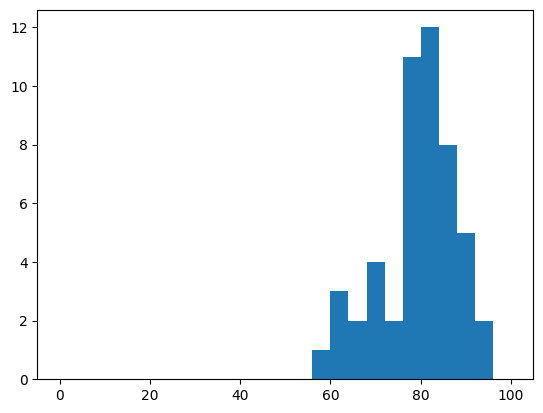

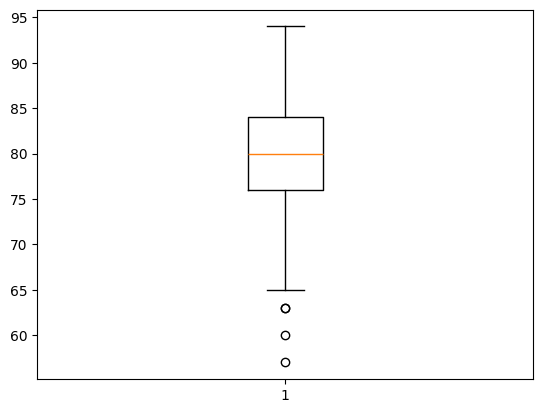

In [12]:
plt.hist(math, bins=25, range=(0, 100))
plt.show()
plt.boxplot(math)
plt.show()

In [13]:
print( score_df.corr(method="pearson") )
print( score_df.corr(method="spearman") )
print( score_df.corr(method="kendall") )

print('\n')
print(pearsonr(english, math))
print(spearmanr(english, math))
print(kendalltau(english, math))

              english  mathematics
english      1.000000     0.723741
mathematics  0.723741     1.000000
              english  mathematics
english      1.000000     0.704585
mathematics  0.704585     1.000000
              english  mathematics
english      1.000000     0.531316
mathematics  0.531316     1.000000


PearsonRResult(statistic=np.float64(0.7237414863069243), pvalue=np.float64(2.8760870522821537e-09))
SignificanceResult(statistic=np.float64(0.7045853895409744), pvalue=np.float64(1.1269964723609888e-08))
SignificanceResult(statistic=np.float64(0.53131572579566), pvalue=np.float64(1.134129795679461e-07))


[ 0.84290689 -8.10849513]
 
0.8429 x - 8.108


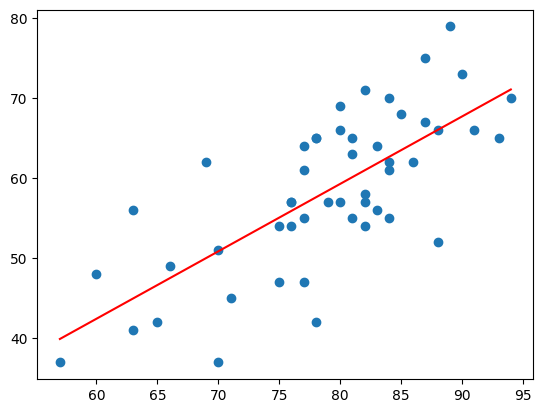

In [14]:
poly_fit = np.polyfit(math, english, 1)
print(poly_fit)

poly_1d = np.poly1d(poly_fit)
print(poly_1d)

xs = np.linspace(math.min(), math.max())
ys = poly_1d(xs)

plt.scatter(math, english)
plt.plot(xs, ys, c='r')
plt.show()

              english  mathematics
english      1.000000     0.723741
mathematics  0.723741     1.000000


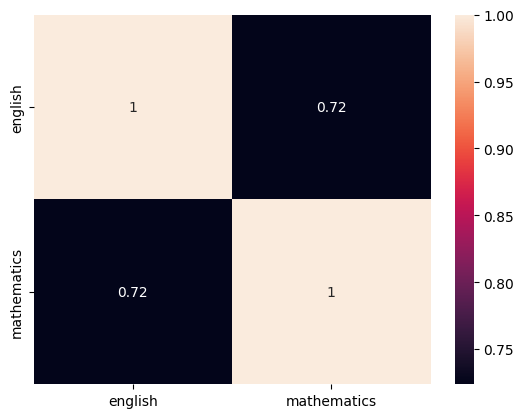

In [16]:
corr = score_df.corr()
print(corr)

sns.heatmap(corr, annot=True)
plt.show()